In [8]:
import pandas as pd

df = pd.read_csv('../results/Hyperparams.csv')
df = df.sort_values(['alpha', 'beta'], ascending=[True, True])
display(df)

,Name,State,alpha,beta,version,after_test_recall@20,after_test_ndcg@20,unlearn_positive_rank_drop_ratio,unlearn_positive_rank_change,unlearn_positive_avg_rank_unlearned,retraining_recall@100,retraining_ndcg@100,dataset,script_name,attack,gcn_layers,Runtime
35,graceful-jazz-3001,finished,15,0.0,v7,0.059588,0.046523,0.587381,-6.544947,67.554439,0.910774,0.933874,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1455
31,trim-wildflower-3032,finished,15,0.1,v7,0.059631,0.046550,0.616415,-7.212730,68.222222,0.910822,0.933910,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1406
25,radiant-cloud-3063,finished,15,0.2,v7,0.059617,0.046552,0.646566,-7.944724,68.954216,0.910864,0.933941,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1413
15,young-surf-3094,finished,15,0.3,v7,0.059617,0.046573,0.672250,-8.867672,69.877164,0.910910,0.933974,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1431
10,genial-paper-3111,finished,15,0.4,v7,0.059649,0.046603,0.711334,-10.109994,71.119486,0.910929,0.933985,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1409
24,sage-cloud-3129,finished,15,0.5,v7,0.059678,0.046632,0.752094,-11.632049,72.641541,0.910880,0.933944,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1403
37,wise-aardvark-3145,finished,15,0.6,v7,0.059706,0.046655,0.792853,-13.398660,74.408152,0.910663,0.933769,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1837
41,proud-totem-3168,finished,15,0.7,v7,0.059749,0.046674,0.838638,-15.634283,76.643774,0.909917,0.933180,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,2051
47,swept-sponge-3197,finished,15,0.8,v7,0.059955,0.046865,0.901173,-19.101619,80.111111,0.907547,0.931285,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1401
53,dulcet-lake-3220,finished,15,0.9,v7,0.060399,0.047194,0.949749,-26.942490,87.951982,0.895521,0.921405,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1412


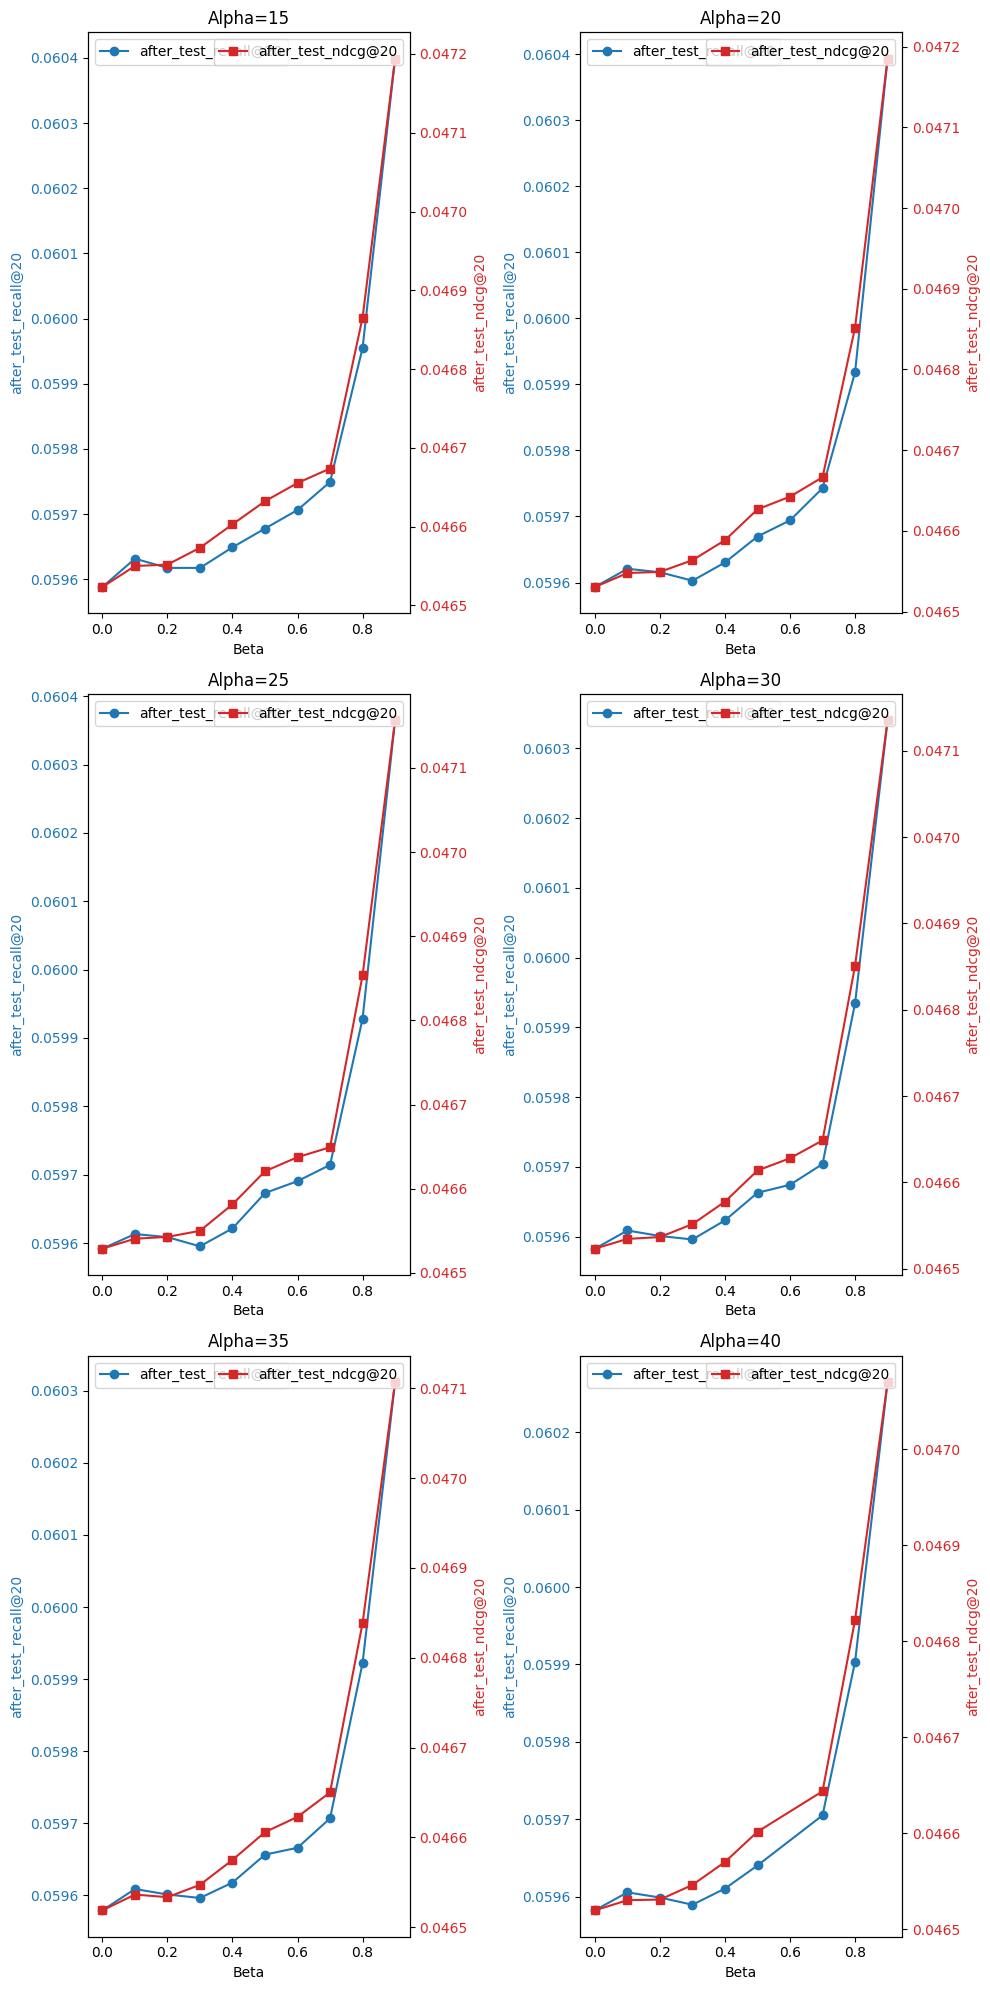

In [18]:
# alpha별로 beta 변화에 따른 recall, ndcg 시각화 (좌우 y축)
import matplotlib.pyplot as plt
metrics = ['after_test_recall@20', 'after_test_ndcg@20']  # 필요한 열 이름으로 수정
unique_alphas = sorted(df['alpha'].unique())
fig, axes = plt.subplots(3, 2, figsize=(10, 20), sharey=False)
axes = axes.flatten()
for idx, alpha in enumerate(unique_alphas):
    subset = df[df['alpha'] == alpha]
    if 'beta' in subset.columns:
        unique_betas = sorted(subset['beta'].unique())
        ax1 = axes[idx]
        ax2 = ax1.twinx()
        # 왼쪽 y축: recall
        ax1.plot(unique_betas, [subset[subset['beta']==b][metrics[0]].mean() for b in unique_betas], marker='o', color='tab:blue', label=metrics[0])
        ax1.set_ylabel(metrics[0], color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        # 오른쪽 y축: ndcg
        ax2.plot(unique_betas, [subset[subset['beta']==b][metrics[1]].mean() for b in unique_betas], marker='s', color='tab:red', label=metrics[1])
        ax2.set_ylabel(metrics[1], color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        ax1.set_title(f'Alpha={alpha}')
        ax1.set_xlabel('Beta')
        ax1.legend([metrics[0]], loc='upper left')
        ax2.legend([metrics[1]], loc='upper right')
plt.tight_layout()
plt.show()

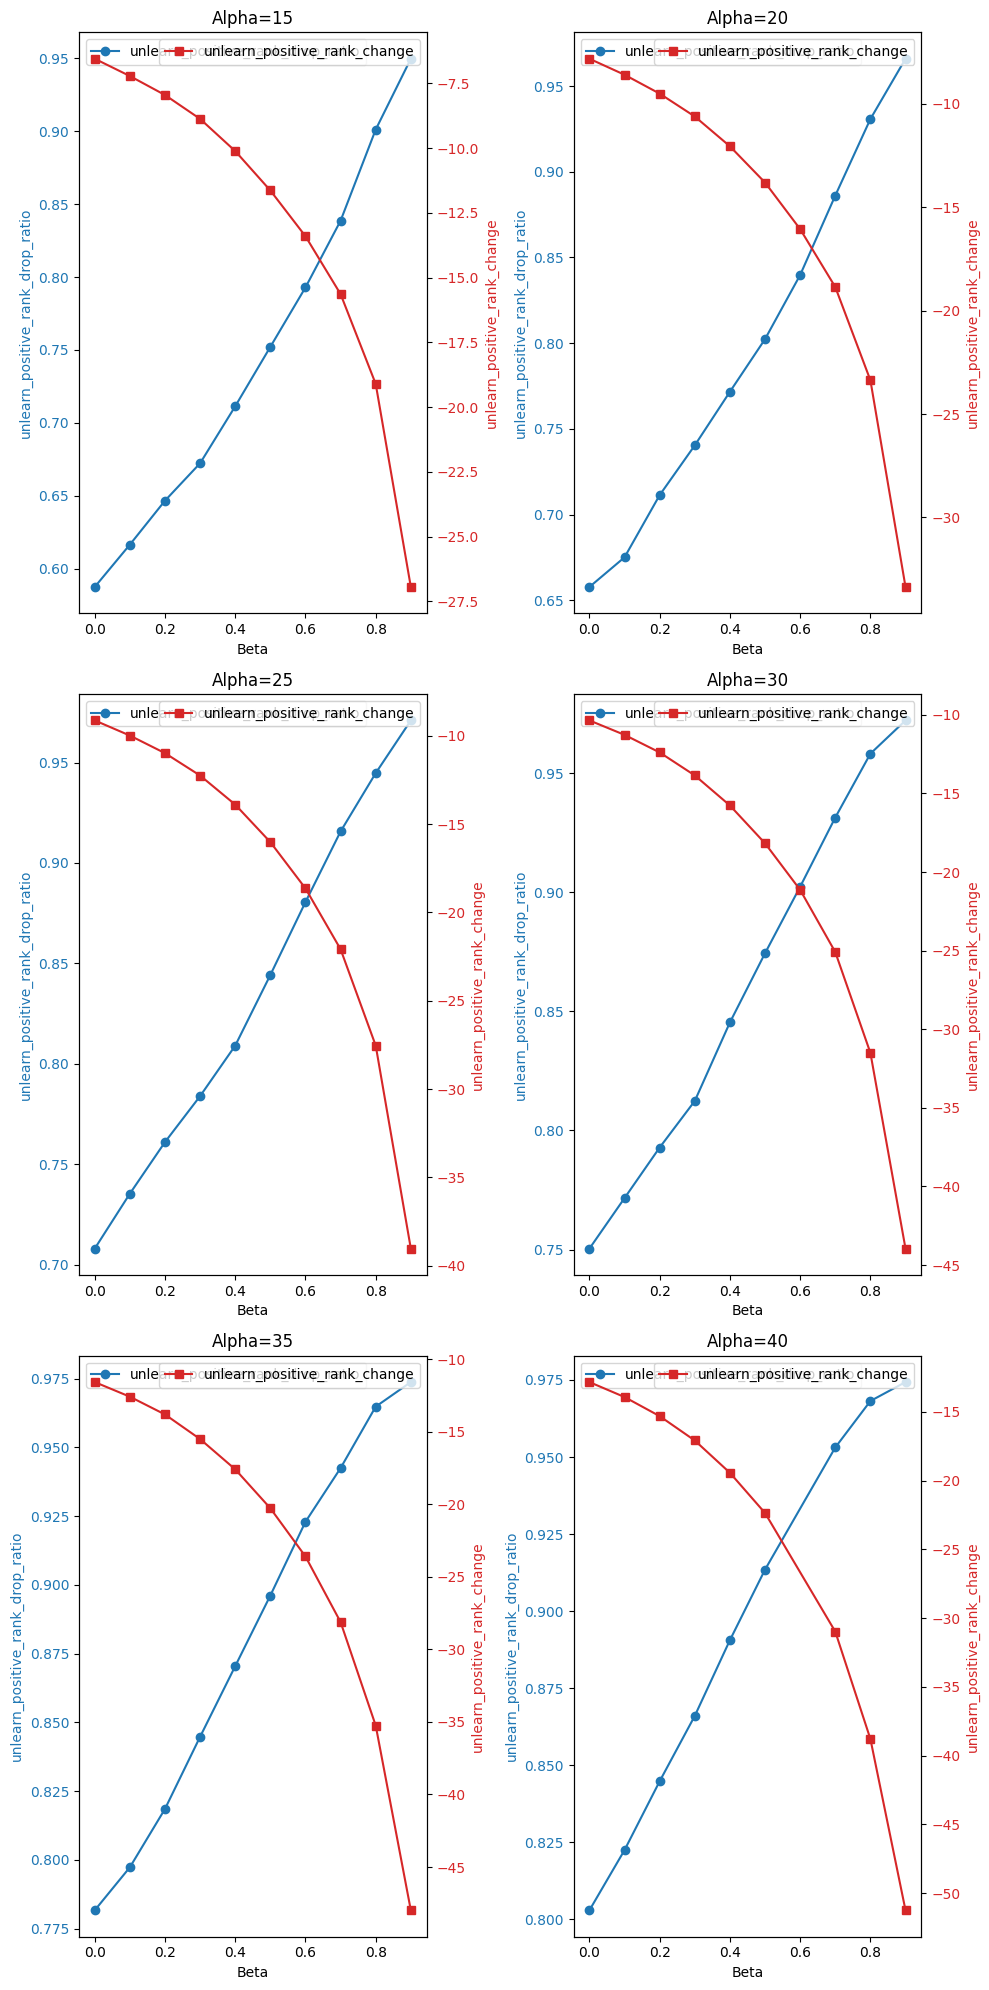

In [15]:
# alpha별로 beta 변화에 따른 두 metric을 좌우 y축으로 비교 시각화
import matplotlib.pyplot as plt
metrics = ['unlearn_positive_rank_drop_ratio', 'unlearn_positive_rank_change']  # 필요한 열 이름으로 수정
unique_alphas = sorted(df['alpha'].unique())
fig, axes = plt.subplots(3, 2, figsize=(10, 20), sharey=False)
axes = axes.flatten()
for idx, alpha in enumerate(unique_alphas):
    subset = df[df['alpha'] == alpha]
    if 'beta' in subset.columns:
        unique_betas = sorted(subset['beta'].unique())
        ax1 = axes[idx]
        ax2 = ax1.twinx()
        # 왼쪽 y축: drop ratio (0~1)
        ax1.plot(unique_betas, [subset[subset['beta']==b][metrics[0]].mean() for b in unique_betas], marker='o', color='tab:blue', label=metrics[0])
        ax1.set_ylabel(metrics[0], color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        # 오른쪽 y축: rank change (음수 가능)
        ax2.plot(unique_betas, [subset[subset['beta']==b][metrics[1]].mean() for b in unique_betas], marker='s', color='tab:red', label=metrics[1])
        ax2.set_ylabel(metrics[1], color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        ax1.set_title(f'Alpha={alpha}')
        ax1.set_xlabel('Beta')
        ax1.legend([metrics[0]], loc='upper left')
        ax2.legend([metrics[1]], loc='upper right')
plt.tight_layout()
plt.show()

In [7]:
# 각 metric별로 가장 높은/낮은 alpha, beta 조합 찾기
for metric in ['unlearn_positive_rank_drop_ratio', 'unlearn_positive_rank_change', 'unlearn_positive_avg_rank_unlearned']:
    if(metric != 'unlearn_positive_rank_change'):  # rank_change는 음수도 가능하므로 절대값 기준으로 최대/최소 찾기
        best_row = df.loc[df[metric].abs().idxmax()]
    best_row = df.loc[df[metric].idxmin()]
    
    print(f"{metric} 최대: alpha={best_row['alpha']}, beta={best_row['beta']}, 값={best_row[metric]}")

unlearn_positive_rank_drop_ratio 최대: alpha=0.0, beta=15, 값=0.5873813512004467
unlearn_positive_rank_change 최대: alpha=0.9, beta=40, 값=-51.2568397543272
unlearn_positive_avg_rank_unlearned 최대: alpha=0.0, beta=15, 값=67.55443886097153
